# Supervised clustering of 6dpf brains

In [1]:
import anndata as ad
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import scanpy.external as sce

In [2]:
sc.logging.print_header()

scanpy==1.9.8 anndata==0.10.5.post1 umap==0.5.5 numpy==1.26.4 scipy==1.12.0 pandas==2.2.1 scikit-learn==1.4.1.post1 statsmodels==0.14.1 igraph==0.11.4 pynndescent==0.5.11


In [3]:
%matplotlib inline
mpl.rcParams["figure.figsize"] = (7.0, 7.0)

## Reading and aggregating

In [4]:
aggregation = pd.read_csv("../samples.csv")
aggregation

,library_id,sample_id,population
0,Cave_1_CKDL240012824-1A_225CYJLT4,Cave_1,cave
1,Cave_2_CKDL240012825-1A_225CYJLT4,Cave_2,cave
2,CF1_CKDL230043822-1A_223HWWLT4,CF1,cave
3,CF2_CKDL230043823-1A_223HWWLT4,CF2,cave
4,SF1_CKDL230043824-1A_223HWWLT4,SF1,surface
5,SF2_CKDL230043825-1A_223HWWLT4,SF2,surface
6,Surface_1_CKDL240012801-1A_225CYJLT4,Surface_1,surface
7,Surface_2_CKDL240012826-1A_225CYJLT4,Surface_2,surface


In [5]:
adatas = []
for idx, row in aggregation.iterrows():
    this_adata = sc.read_10x_h5(
        f"../2-cellbender/out/{row.sample_id}/{row.sample_id}.cellbender_filtered.h5"
    )
    this_adata.obs["sample_id"] = row["sample_id"]
    this_adata.obs["population"] = row.population
    adatas.append(this_adata)

adata = ad.concat(adatas)
adata.obs_names_make_unique()
adata

/mnt/pixstor/data/esrbhb/miniforge3/envs/scanpy/lib/python3.12/site-packages/anndata/_core/anndata.py:1906: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


AnnData object with n_obs × n_vars = 151055 × 30363
    obs: 'sample_id', 'population'

In [6]:
adata.obs.groupby("sample_id").size()

sample_id
CF1           7800
CF2           7998
Cave_1       34177
Cave_2       41172
SF1          10644
SF2          11009
Surface_1    19698
Surface_2    18557
dtype: int64

## Preprocessing

### Filtering

In [7]:
sc.pp.filter_cells(adata, min_genes=1)

In [8]:
ribo_genes = adata.var_names.str.contains("^RP[LS]", case=False)
adata.obs["percent_ribo"] = (
    np.sum(adata[:, ribo_genes].X, axis=1).A1 / np.sum(adata.X, axis=1).A1 * 100
)

/mnt/pixstor/data/esrbhb/miniforge3/envs/scanpy/lib/python3.12/site-packages/scanpy/plotting/_utils.py:716: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  color = color[sort]


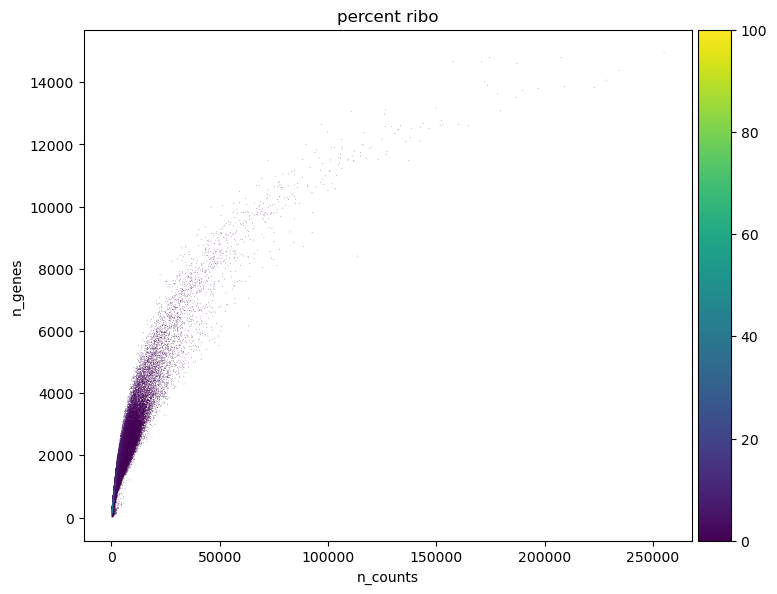

In [9]:
sc.pp.filter_genes(adata, min_cells=3)
adata.obs["n_counts"] = adata.X.sum(axis=1).A1
sc.pl.scatter(adata, x="n_counts", y="n_genes", color="percent_ribo")

/mnt/pixstor/data/esrbhb/miniforge3/envs/scanpy/lib/python3.12/site-packages/scanpy/plotting/_anndata.py:839: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(
/mnt/pixstor/data/esrbhb/miniforge3/envs/scanpy/lib/python3.12/site-packages/scanpy/plotting/_anndata.py:839: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  ax = sns.violinplot(
/mnt/pixstor/data/esrbhb/miniforge3/envs/scanpy/lib/python3.12/site-packages/scanpy/plotting/_anndata.py:839: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(
/mnt/pixstor/data/esrbhb/miniforge3/envs/scanpy/lib/python3.12/site-packages/scanpy/plotting/_annd

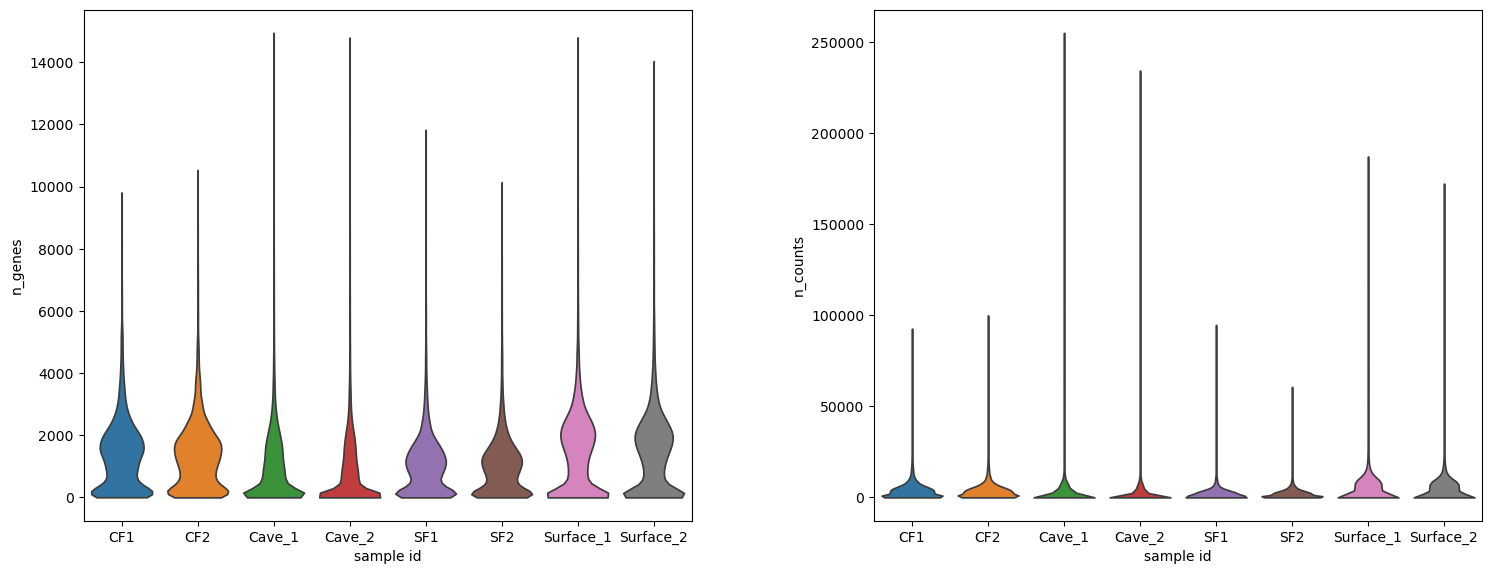

In [10]:
sc.pl.violin(adata, ["n_genes", "n_counts"], groupby="sample_id", stripplot=False)

/mnt/pixstor/data/esrbhb/miniforge3/envs/scanpy/lib/python3.12/site-packages/scanpy/plotting/_anndata.py:839: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(
/mnt/pixstor/data/esrbhb/miniforge3/envs/scanpy/lib/python3.12/site-packages/scanpy/plotting/_anndata.py:839: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  ax = sns.violinplot(


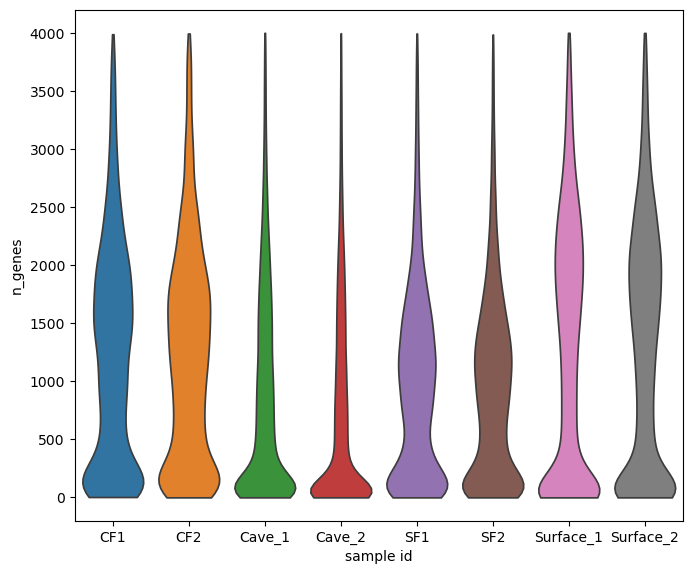

In [11]:
sc.pl.violin(
    adata[adata.obs.n_genes < 4000], "n_genes", groupby="sample_id", stripplot=False
)

/mnt/pixstor/data/esrbhb/miniforge3/envs/scanpy/lib/python3.12/site-packages/scanpy/plotting/_anndata.py:839: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(
/mnt/pixstor/data/esrbhb/miniforge3/envs/scanpy/lib/python3.12/site-packages/scanpy/plotting/_anndata.py:839: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  ax = sns.violinplot(


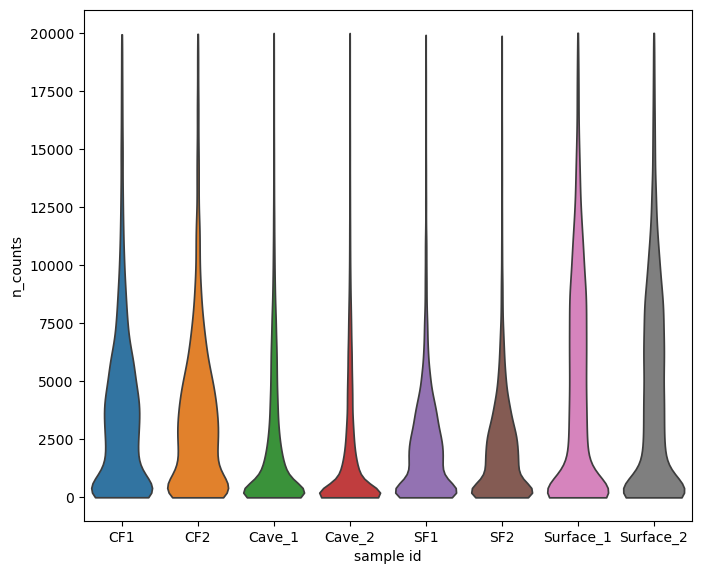

In [12]:
sc.pl.violin(
    adata[adata.obs.n_counts < 20000], "n_counts", groupby="sample_id", stripplot=False
)

/mnt/pixstor/data/esrbhb/miniforge3/envs/scanpy/lib/python3.12/site-packages/scanpy/plotting/_anndata.py:839: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(
/mnt/pixstor/data/esrbhb/miniforge3/envs/scanpy/lib/python3.12/site-packages/scanpy/plotting/_anndata.py:839: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  ax = sns.violinplot(


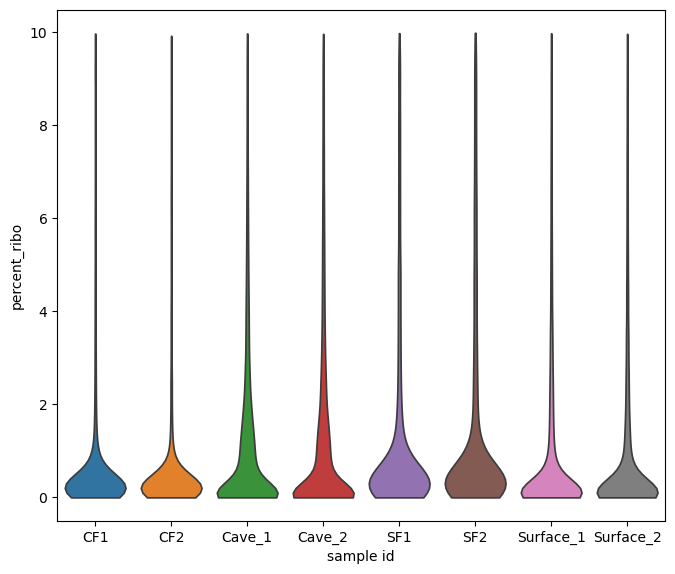

In [13]:
sc.pl.violin(
    adata[adata.obs.percent_ribo < 10],
    ["percent_ribo"],
    groupby="sample_id",
    stripplot=False,
)

These cutoffs are chosen based on the plots above.

In [14]:
sc.pp.filter_cells(adata, min_genes=400)
sc.pp.filter_cells(adata, max_genes=4000)
sc.pp.filter_cells(adata, max_counts=10000)
adata = adata[adata.obs["percent_ribo"] <= 2, :]
adata

View of AnnData object with n_obs × n_vars = 71251 × 29271
    obs: 'sample_id', 'population', 'n_genes', 'percent_ribo', 'n_counts'
    var: 'n_cells'
    uns: 'sample_id_colors'

Now, we have our post-filtering cell counts per library.

In [15]:
adata.obs.groupby("sample_id").size()

/tmp/ipykernel_3177827/2234999136.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  adata.obs.groupby("sample_id").size()


sample_id
CF1           4775
CF2           5159
Cave_1       15389
Cave_2       16237
SF1           5706
SF2           5736
Surface_1     8829
Surface_2     9420
dtype: int64

In [16]:
adata.write("raw_counts.h5ad")  # we'll need this later, for DE analysis

In [17]:
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)
adata.raw = adata
sc.pp.highly_variable_genes(adata)
adata = adata[:, adata.var.highly_variable]
sc.pp.regress_out(adata, ["n_counts"])
sc.pp.scale(adata)

/mnt/pixstor/data/esrbhb/miniforge3/envs/scanpy/lib/python3.12/site-packages/scanpy/preprocessing/_normalization.py:169: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)
/mnt/pixstor/data/esrbhb/miniforge3/envs/scanpy/lib/python3.12/site-packages/scanpy/preprocessing/_highly_variable_genes.py:226: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  disp_grouped = df.groupby("mean_bin")["dispersions"]


### PCA

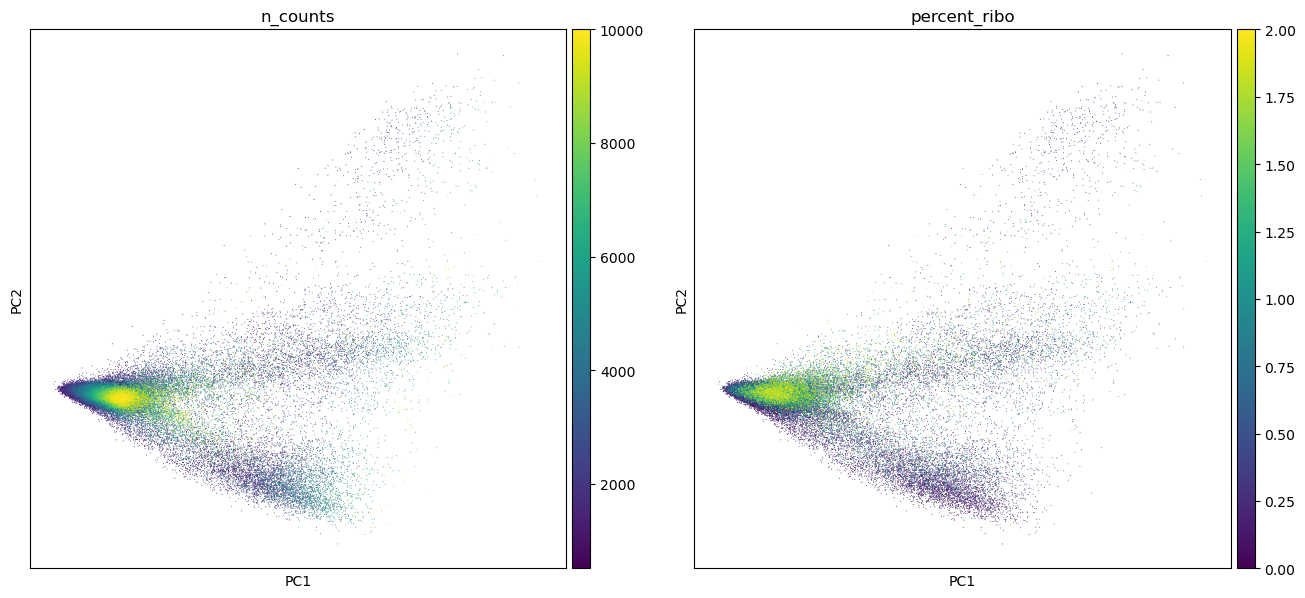

In [18]:
sc.tl.pca(adata)
sc.pl.pca(adata, color=["n_counts", "percent_ribo"])

/mnt/pixstor/data/esrbhb/miniforge3/envs/scanpy/lib/python3.12/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/mnt/pixstor/data/esrbhb/miniforge3/envs/scanpy/lib/python3.12/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


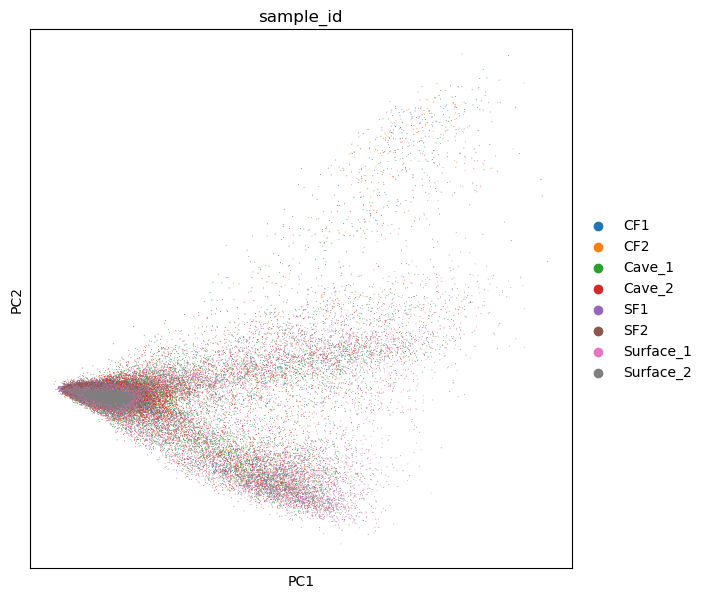

In [19]:
sc.pl.pca(adata, color=["sample_id"])

### Harmony integration

In [20]:
sce.pp.harmony_integrate(adata, "sample_id")

2025-08-27 11:17:43,958 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2025-08-27 11:18:00,064 - harmonypy - INFO - sklearn.KMeans initialization complete.
2025-08-27 11:18:00,421 - harmonypy - INFO - Iteration 1 of 10
2025-08-27 11:18:16,296 - harmonypy - INFO - Iteration 2 of 10
2025-08-27 11:18:32,205 - harmonypy - INFO - Iteration 3 of 10
2025-08-27 11:18:48,064 - harmonypy - INFO - Iteration 4 of 10
2025-08-27 11:19:03,953 - harmonypy - INFO - Iteration 5 of 10
2025-08-27 11:19:16,361 - harmonypy - INFO - Iteration 6 of 10
2025-08-27 11:19:32,293 - harmonypy - INFO - Iteration 7 of 10
2025-08-27 11:19:38,449 - harmonypy - INFO - Iteration 8 of 10
2025-08-27 11:19:44,519 - harmonypy - INFO - Iteration 9 of 10
2025-08-27 11:19:50,682 - harmonypy - INFO - Iteration 10 of 10
2025-08-27 11:19:56,755 - harmonypy - INFO - Converged after 10 iterations


/mnt/pixstor/data/esrbhb/miniforge3/envs/scanpy/lib/python3.12/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/mnt/pixstor/data/esrbhb/miniforge3/envs/scanpy/lib/python3.12/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


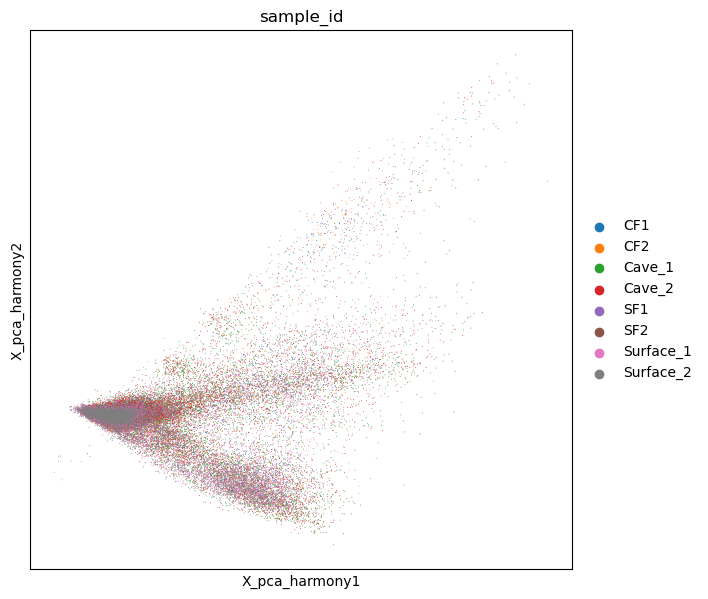

In [21]:
sc.pl.embedding(adata, basis="X_pca_harmony", color=["sample_id"])

## Clustering

In [22]:
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=20, use_rep="X_pca_harmony")
sc.tl.umap(adata)

/mnt/pixstor/data/esrbhb/miniforge3/envs/scanpy/lib/python3.12/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/mnt/pixstor/data/esrbhb/miniforge3/envs/scanpy/lib/python3.12/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


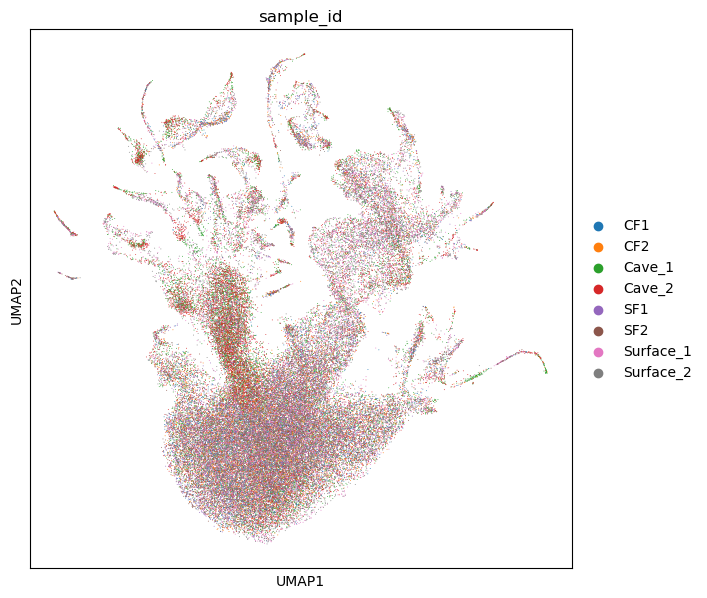

In [23]:
sc.tl.umap(adata)
sc.pl.umap(adata, color="sample_id")

/mnt/pixstor/data/esrbhb/miniforge3/envs/scanpy/lib/python3.12/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/mnt/pixstor/data/esrbhb/miniforge3/envs/scanpy/lib/python3.12/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/mnt/pixstor/data/esrbhb/miniforge3/envs/scanpy/lib/python3.12/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning

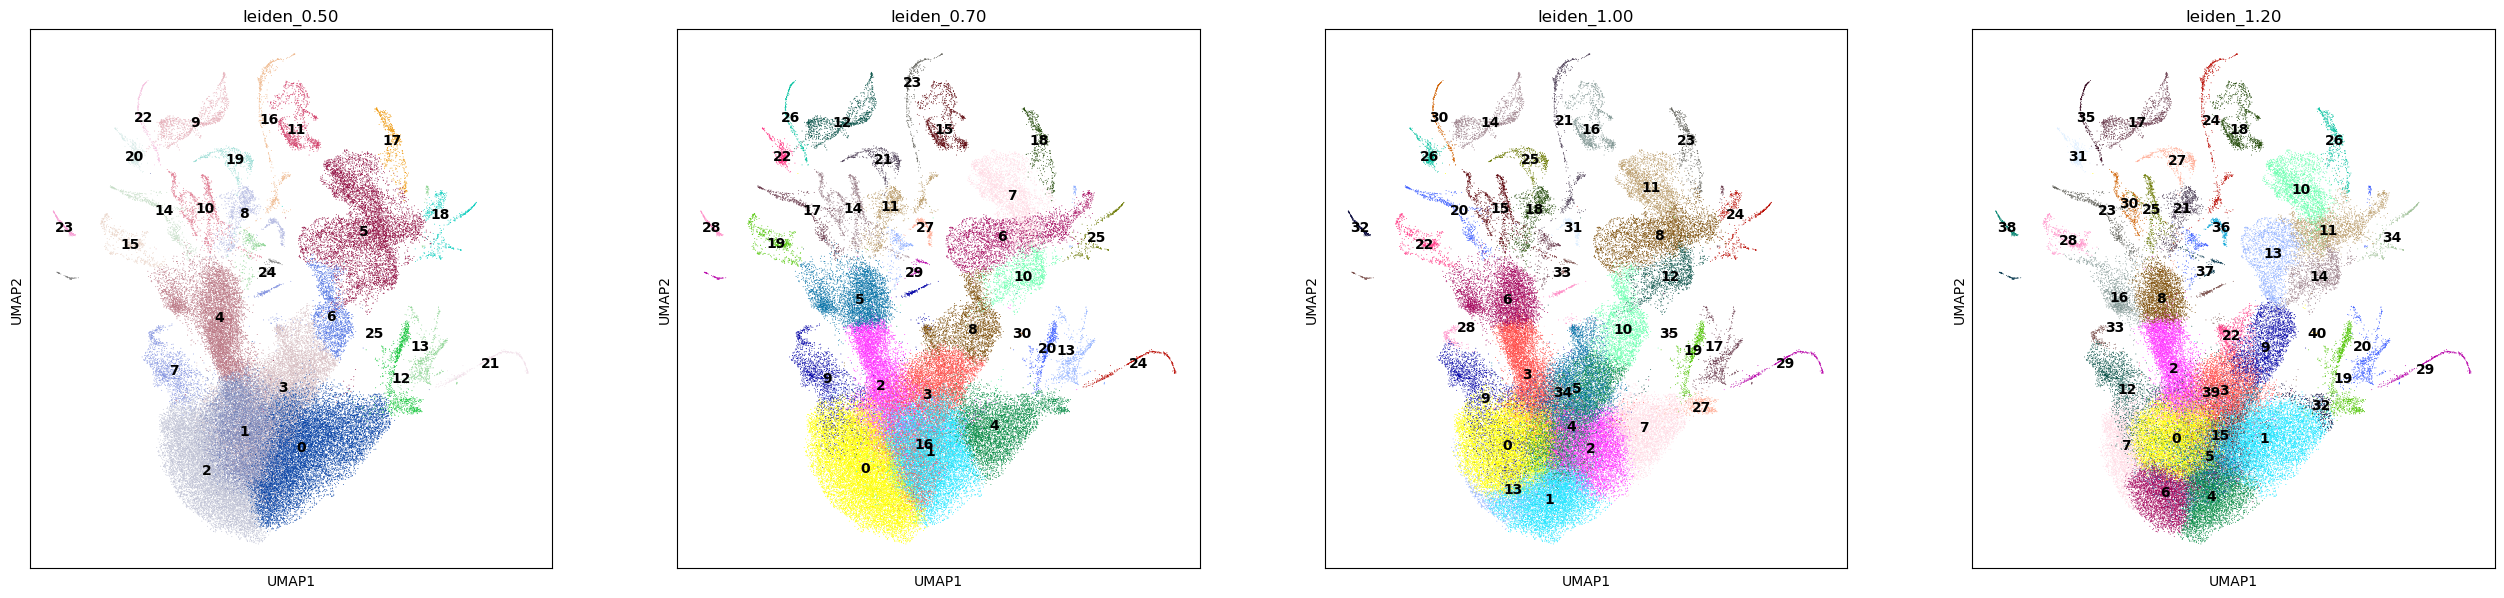

In [24]:
resolutions = [0.5, 0.7, 1.0, 1.2]
for resolution in resolutions:
    sc.tl.leiden(adata, resolution=resolution, key_added=f"leiden_{resolution:.2f}")
sc.pl.umap(adata, color=[f"leiden_{r:.2f}" for r in resolutions], legend_loc="on data")

## Marker genes

In [25]:
for resolution in resolutions:
    sc.tl.rank_genes_groups(
        adata,
        groupby=f"leiden_{resolution:.2f}",
        key_added=f"rank_genes_groups_res_{resolution:.2f}",
    )

/mnt/pixstor/data/esrbhb/miniforge3/envs/scanpy/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:396: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, 'names'] = self.var_names[global_indices]
/mnt/pixstor/data/esrbhb/miniforge3/envs/scanpy/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:398: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, 'scores'] = scores[global_indices]
/mnt/pixstor/data/esrbhb/miniforge3/envs/scanpy/lib/python3.12/site-packages/scanpy/t

/mnt/pixstor/data/esrbhb/miniforge3/envs/scanpy/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:396: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, 'names'] = self.var_names[global_indices]
/mnt/pixstor/data/esrbhb/miniforge3/envs/scanpy/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:398: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, 'scores'] = scores[global_indices]
/mnt/pixstor/data/esrbhb/miniforge3/envs/scanpy/lib/python3.12/site-packages/scanpy/t

/mnt/pixstor/data/esrbhb/miniforge3/envs/scanpy/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:396: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, 'names'] = self.var_names[global_indices]
/mnt/pixstor/data/esrbhb/miniforge3/envs/scanpy/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:398: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, 'scores'] = scores[global_indices]
/mnt/pixstor/data/esrbhb/miniforge3/envs/scanpy/lib/python3.12/site-packages/scanpy/t

In [26]:
adata

AnnData object with n_obs × n_vars = 71251 × 3282
    obs: 'sample_id', 'population', 'n_genes', 'percent_ribo', 'n_counts', 'leiden_0.50', 'leiden_0.70', 'leiden_1.00', 'leiden_1.20'
    var: 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'sample_id_colors', 'log1p', 'hvg', 'pca', 'neighbors', 'umap', 'leiden', 'leiden_0.50_colors', 'leiden_0.70_colors', 'leiden_1.00_colors', 'leiden_1.20_colors', 'rank_genes_groups_res_0.50', 'rank_genes_groups_res_0.70', 'rank_genes_groups_res_1.00', 'rank_genes_groups_res_1.20'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

In [27]:
def make_markers_table(markers_key="rank_genes_groups", leiden_key="leiden"):
    names_df = pd.DataFrame(adata.uns[markers_key]["names"])
    pvals_df = pd.DataFrame(adata.uns[markers_key]["pvals_adj"])
    lfc_df = pd.DataFrame(adata.uns[markers_key]["logfoldchanges"])

    with open(f"{markers_key}.csv", "w") as markers_out:
        print(
            ",".join(["cluster", "gene", "pval_adj", "LFC", "pct.1", "pct.2"]),
            file=markers_out,
        )
        for cluster in sorted(map(int, adata.obs[leiden_key].unique())):
            names = names_df.iloc[:, cluster]
            pvals = pvals_df.iloc[:, cluster]
            lfcs = lfc_df.iloc[:, cluster]
            for name, pval, lfc in zip(names, pvals, lfcs):
                if pval < 1e-2 and lfc > 1:
                    pct1 = (
                        np.sum(
                            adata.raw.X[
                                adata.obs[leiden_key] == str(cluster),
                                adata.raw.var_names == name,
                            ]
                            > 0
                        )
                        / sum(adata.obs[leiden_key] == str(cluster))
                        * 100
                    )
                    pct2 = (
                        np.sum(
                            adata.raw.X[
                                adata.obs[leiden_key] != str(cluster),
                                adata.raw.var_names == name,
                            ]
                            > 0
                        )
                        / sum(adata.obs[leiden_key] != str(cluster))
                        * 100
                    )
                    print(
                        ",".join(map(str, [cluster, name, pval, lfc, pct1, pct2])),
                        file=markers_out,
                    )

In [28]:
adata.write_h5ad("initial_clusters_all_resolutions.h5ad")

In [ ]:
for resolution in resolutions:
    make_markers_table(
        f"rank_genes_groups_res_{resolution:.2f}", f"leiden_{resolution:.2f}"
    )